# Hahn-Spin-Echo – TE-Reihe

Simuliert Hahn-Spin-Echos für verschiedene Echo-Zeiten TE und zeigt T₂-gewichteten Signal-Zerfall.

**Sequenz:** 90° Gauß → delay(TE/2) → 180° Gauß (Phase=90°) → delay(TE/2) → ADC

Durch die B₀-Inhomogenität (config_1pool_se.yaml: `b0_inhom = 3×10⁻⁸`) dephesen die Isochromaten nach dem 90°-Puls (T₂* ≈ 10 ms). Der 180°-Puls kehrt die Phase um, woraufhin sich das Echo bei t = TE bildet. Da T₂ = 71 ms gilt, nimmt die Echo-Amplitude mit T₂ ab.

In [1]:
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import pypulseq as pp
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from scipy.optimize import curve_fit

from bmc.simulate import simulate
from bmc.utils.seq.write import write_seq
from bmc.utils.results import save_simulation, load_simulation

## Einstellungen

In [2]:
# ── Pfade ──────────────────────────────────────────────────────────────────
wdir        = Path().resolve().parent  # one level up: optim/
config_path = wdir / 'sim_lib' / 'config_1pool_se.yaml'
seq_tmp_dir = wdir / 'seq_lib' / 'spin_echo'
seq_tmp_dir.mkdir(parents=True, exist_ok=True)

series_label = f"spin_echo_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
series_dir   = wdir / 'results' / 'simulations' / series_label
series_dir.mkdir(parents=True, exist_ok=True)

# ── TE-Reihe ───────────────────────────────────────────────────────────────
TE_values_ms = np.array([50, 100, 150, 200, 250])   # Echo-Zeiten [ms]

# ── Sequenz-Parameter ──────────────────────────────────────────────────────
sys = pp.Opts(
    max_grad=500,
    grad_unit='mT/m',
    max_slew=1e9,
    slew_unit='T/m/s',
    rf_ringdown_time=0,
    rf_dead_time=0,
    rf_raster_time=1e-6,
    gamma=42576400,
    grad_raster_time=1e-6,
)

B0       = 17          # [T]
t_pulse  = 2e-3        # [s]  Pulsdauer (90° und 180° gleich)
adc_time = 300e-3      # [s]  Aufzeichnungsfenster nach Echo

GAMMA_HZ = sys.gamma * 1e-6
freq_hz  = B0 * GAMMA_HZ

# ── Isochromaten ───────────────────────────────────────────────────────────
low, high, n_iso = -1e-3, 1e-3, 1000
z_pos = np.linspace(low, high, n_iso)
z_pos = torch.tensor(z_pos)
z_pos = torch.cat((z_pos, torch.tensor([0.0])))
z_pos = torch.sort(z_pos).values

print(f"TE-Werte:   {TE_values_ms} ms")
print(f"adc_time:   {adc_time*1e3:.0f} ms")
print(f"Ergebnisse: {series_dir}")

TE-Werte:   [ 50 100 150 200 250] ms
adc_time:   300 ms
Ergebnisse: /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616


## Sequenzen erstellen, simulieren und speichern

Für jedes TE wird eine separate Sequenz erzeugt:
```
90°(Gauß) → delay(TE/2) → 180°(Gauß, Phase=π/2) → delay(TE/2) → ADC
```
Das Echo formt sich am Ende der zweiten TE/2-Verzögerung bei
t_echo = t_pulse + TE/2 + t_pulse + TE/2 = 2·t_pulse + TE.

In [3]:
result_dirs = {}
echo_times  = {}   # te_ms -> absolute echo time [ms]

for te_ms in TE_values_ms:
    te_s    = float(te_ms) * 1e-3
    te_half = te_s / 2.0

    print(f"\n── TE = {te_ms} ms ──")

    defs = {
        'TE':            te_s,
        'b0':            B0,
        'm0_offset':     0,
        'n_ETM':         1,
        'seq_id_string': f'se_te_{int(te_ms):04d}ms',
    }
    defs['offsets_ppm'] = np.array([defs['m0_offset']])
    defs['num_meas']    = int(defs['offsets_ppm'].size)
    defs['freq']        = freq_hz

    seq = pp.Sequence()

    # 90° Anregungspuls
    rf90 = pp.make_gauss_pulse(
        flip_angle=np.pi / 2,
        system=sys,
        duration=t_pulse,
        center_pos=0.5,
        freq_offset=0.0,
        phase_offset=0.0,
        return_gz=False,
    )
    rf90.freq_offset = 0.0
    seq.add_block(rf90)

    # Erste TE/2-Verzögerung (Dephasing)
    seq.add_block(pp.make_delay(te_half))

    # 180° Refokussierungspuls (CPMG-Phasenkonvention: +90° gegenüber Anregung)
    rf180 = pp.make_gauss_pulse(
        flip_angle=np.pi,
        system=sys,
        duration=t_pulse,
        center_pos=0.5,
        freq_offset=0.0,
        phase_offset=np.pi / 2,
        return_gz=False,
    )
    rf180.freq_offset = 0.0
    seq.add_block(rf180)

    # Zweite TE/2-Verzögerung (Rephasing → Echo)
    seq.add_block(pp.make_delay(te_half))

    # ADC-Trigger am Echo-Zeitpunkt
    seq.add_block(pp.make_adc(num_samples=1, duration=1e-3))

    seq_file = seq_tmp_dir / f"se_te_{int(te_ms):04d}ms.seq"
    write_seq(seq=seq, seq_defs=defs, filename=seq_file,
              author='DANIEL MIKSCH', use_matlab_names=True)

    sim = simulate(
        config_file=config_path,
        seq_file=seq_file,
        z_positions=z_pos,
        adc_time=adc_time,
        iso_select=None,
        return_zmag=False,
        show_plot=False,
        webhook=False,
        plt_range=[0, 4],
        n_backlog='ALL',
    )

    out = save_simulation(sim, label=f"se_te_{int(te_ms):04d}ms", results_root=series_dir)
    result_dirs[float(te_ms)] = out
    # Echo-Zeit (Mitte-zu-Mitte-Konvention): 2.5·t_pulse + TE
    # = t_pulse/2 (Mitte 90°) + 2·(t_pulse + TE/2)
    echo_times[float(te_ms)] = (2.5 * t_pulse + te_s) * 1e3   # [ms]
    print(f"   gespeichert: {out.name}  (Echo bei t = {echo_times[float(te_ms)]:.1f} ms)")

print(f"\n✓ Alle {len(TE_values_ms)} Simulationen gespeichert in:\n  {series_dir}")


── TE = 50 ms ──


BMCTool simulation: 100%|██████████| 5/5 [00:08<00:00,  1.76s/it]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616/se_te_0050ms_20260517_225625
   gespeichert: se_te_0050ms_20260517_225625  (Echo bei t = 55.0 ms)

── TE = 100 ms ──


BMCTool simulation: 100%|██████████| 5/5 [00:08<00:00,  1.73s/it]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616/se_te_0100ms_20260517_225634
   gespeichert: se_te_0100ms_20260517_225634  (Echo bei t = 105.0 ms)

── TE = 150 ms ──


...

[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616/se_te_0150ms_20260517_225643
   gespeichert: se_te_0150ms_20260517_225643  (Echo bei t = 155.0 ms)

── TE = 200 ms ──


BMCTool simulation: 100%|██████████| 5/5 [00:09<00:00,  1.95s/it]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616/se_te_0200ms_20260517_225653
   gespeichert: se_te_0200ms_20260517_225653  (Echo bei t = 205.0 ms)

── TE = 250 ms ──


BMCTool simulation: 100%|██████████| 5/5 [00:09<00:00,  1.87s/it]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616/se_te_0250ms_20260517_225703
   gespeichert: se_te_0250ms_20260517_225703  (Echo bei t = 255.0 ms)

✓ Alle 5 Simulationen gespeichert in:
  /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616


## Ergebnisse laden und plotten

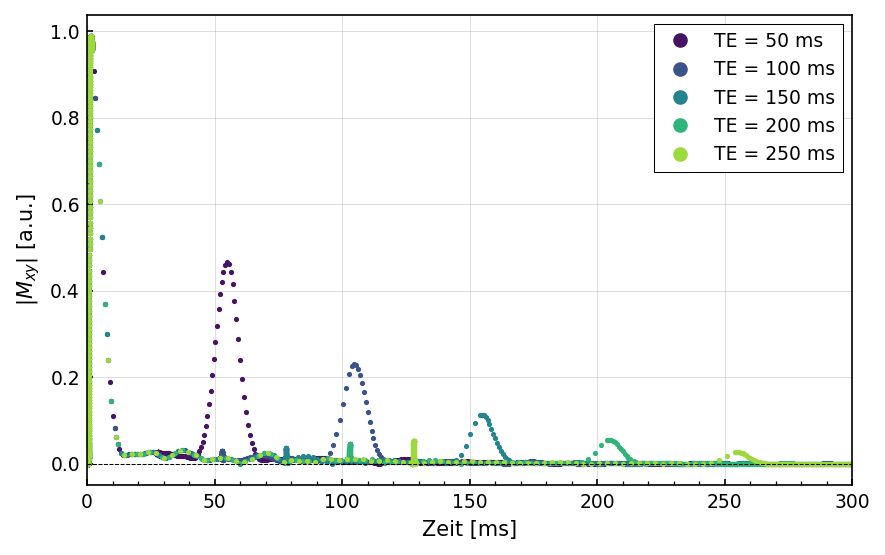

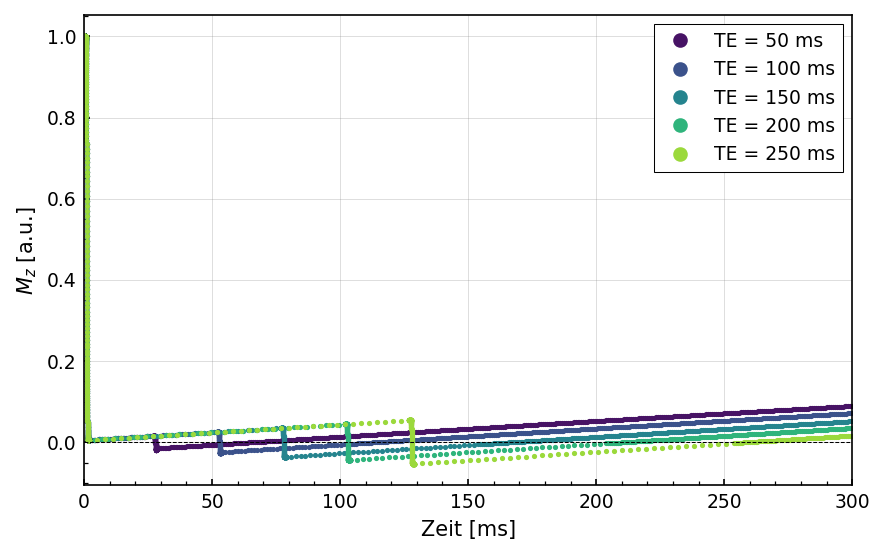


Plots gespeichert in: /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616


In [4]:
import matplotlib as mpl

# ── Plot-Stil ──────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'text.usetex':         False,
    'font.family':         'sans-serif',
    'font.size':           10,
    'axes.labelsize':      10,
    'axes.titlesize':      11,
    'legend.fontsize':     9,
    'xtick.labelsize':     9,
    'ytick.labelsize':     9,
    'axes.linewidth':      0.8,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.size':    3,
    'ytick.major.size':    3,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth':     1.2,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# ── State-Vektor-Indizes (1 Wasser + 1 CEST-Pool) ─────────────────────────
# Layout: [Mx_w, Mx_cest, My_w, My_cest, Mz_w, Mz_cest, M0_w, M0_cest]
n_total_pools = 2   # 1 Wasser + 1 CEST
mz_loc        = 4   # = 2 * n_total_pools

# ── Viridis-Farben ─────────────────────────────────────────────────────────
te_list = sorted(result_dirs.keys())
n_te    = len(te_list)
cmap    = cm.viridis
colors  = [cmap(0.05 + 0.80 * i / max(n_te - 1, 1)) for i in range(n_te)]

MARKER_SIZE = 3
PLOT_XLIM   = 300   # [ms] — x-axis cutoff for all time-course plots

# ── Daten laden ────────────────────────────────────────────────────────────
trans_data  = {}
long_data   = {}
echo_amps   = {}

for te_ms in te_list:
    loaded       = load_simulation(result_dirs[te_ms])
    m_out        = loaded['m_out']
    t            = loaded['t']
    n_iso_loaded = m_out.shape[0]

    m_x = np.sum(m_out[:, 0,            :], axis=0) / n_iso_loaded   # Mx_water
    m_y = np.sum(m_out[:, n_total_pools, :], axis=0) / n_iso_loaded   # My_water
    m_z = np.sum(m_out[:, mz_loc,        :], axis=0) / n_iso_loaded   # Mz_water

    t_ms = t * 1e3
    mxy  = np.abs(m_x + 1j * m_y)

    trans_data[te_ms] = (t_ms, mxy)
    long_data[te_ms]  = (t_ms, m_z)

    # Echo-Amplitude: Mxy am berechneten Echo-Zeitpunkt
    t_echo_ms = echo_times[te_ms]
    idx_echo  = int(np.argmin(np.abs(t_ms - t_echo_ms)))
    echo_amps[te_ms] = float(mxy[idx_echo])

# ── Plot 1: Transversale Magnetisierung ────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 3.8))

for idx, te_ms in enumerate(te_list):
    t_ms, mxy = trans_data[te_ms]
    ax1.plot(t_ms, mxy, '.', color=colors[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'TE = {int(te_ms)} ms')

ax1.set_xlabel('Zeit [ms]')
ax1.set_ylabel('$|M_{xy}|$ [a.u.]')
ax1.set_xlim(0, PLOT_XLIM)
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax1.grid(True, linewidth=0.4, color='gray', alpha=0.3)

leg1 = ax1.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=4)
leg1.get_frame().set_linewidth(0.5)

fig1.tight_layout()
fig1.savefig(series_dir / 'transverse_magnetization.pdf')
fig1.savefig(series_dir / 'transverse_magnetization.png')
plt.show()

# ── Plot 2: Longitudinale Magnetisierung ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 3.8))

for idx, te_ms in enumerate(te_list):
    t_ms, m_z = long_data[te_ms]
    ax2.plot(t_ms, m_z, '.', color=colors[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'TE = {int(te_ms)} ms')

ax2.set_xlabel('Zeit [ms]')
ax2.set_ylabel('$M_z$ [a.u.]')
ax2.set_xlim(0, PLOT_XLIM)
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.grid(True, linewidth=0.4, color='gray', alpha=0.3)

leg2 = ax2.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=4)
leg2.get_frame().set_linewidth(0.5)

fig2.tight_layout()
fig2.savefig(series_dir / 'longitudinal_magnetization.pdf')
fig2.savefig(series_dir / 'longitudinal_magnetization.png')
plt.show()

print(f"\nPlots gespeichert in: {series_dir}")

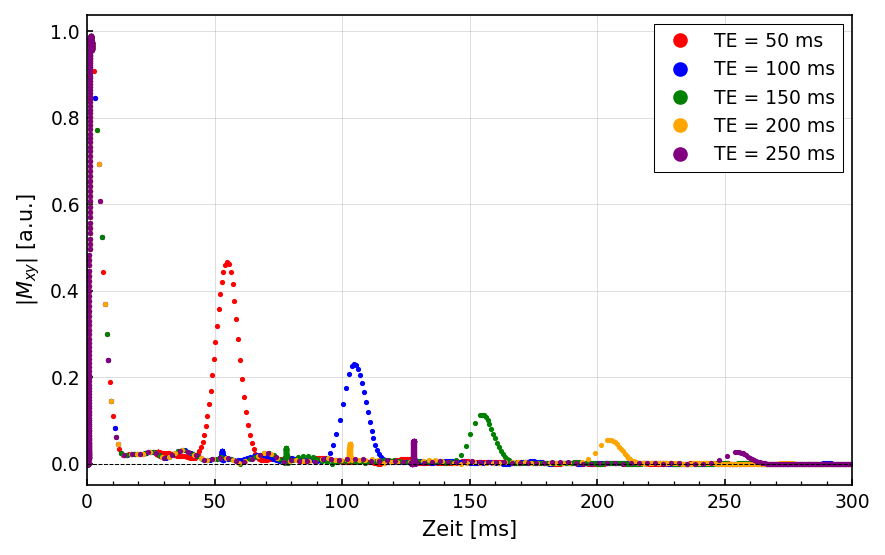

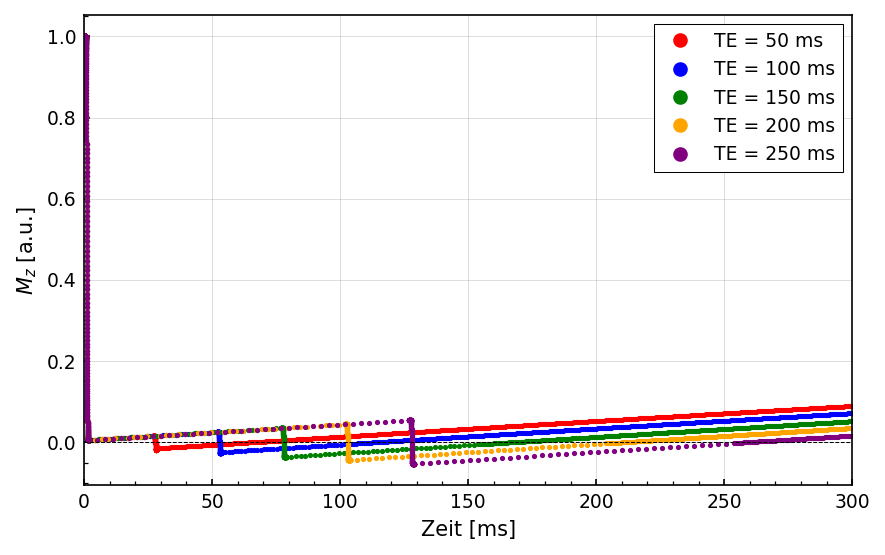

Backup-Plots gespeichert als *_classic.pdf / *_classic.png in:
  /Users/danielmiksch/JupyterLab/optim/results/simulations/spin_echo_20260517_225616


In [5]:
# ── Backup: klassische Farbgebung ──────────────────────────────────────────
COLORS_OLD = ['red', 'blue', 'green', 'orange', 'purple']
colors_old = COLORS_OLD[:n_te]

fig3, ax3 = plt.subplots(figsize=(6, 3.8))
for idx, te_ms in enumerate(te_list):
    t_ms, mxy = trans_data[te_ms]
    ax3.plot(t_ms, mxy, '.', color=colors_old[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'TE = {int(te_ms)} ms')
ax3.set_xlabel('Zeit [ms]')
ax3.set_ylabel('$|M_{xy}|$ [a.u.]')
ax3.set_xlim(0, PLOT_XLIM)
ax3.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax3.grid(True, linewidth=0.4, color='gray', alpha=0.3)
leg3 = ax3.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=4)
leg3.get_frame().set_linewidth(0.5)
fig3.tight_layout()
fig3.savefig(series_dir / 'transverse_magnetization_classic.pdf')
fig3.savefig(series_dir / 'transverse_magnetization_classic.png')
plt.show()

fig4, ax4 = plt.subplots(figsize=(6, 3.8))
for idx, te_ms in enumerate(te_list):
    t_ms, m_z = long_data[te_ms]
    ax4.plot(t_ms, m_z, '.', color=colors_old[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'TE = {int(te_ms)} ms')
ax4.set_xlabel('Zeit [ms]')
ax4.set_ylabel('$M_z$ [a.u.]')
ax4.set_xlim(0, PLOT_XLIM)
ax4.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax4.grid(True, linewidth=0.4, color='gray', alpha=0.3)
leg4 = ax4.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=4)
leg4.get_frame().set_linewidth(0.5)
fig4.tight_layout()
fig4.savefig(series_dir / 'longitudinal_magnetization_classic.pdf')
fig4.savefig(series_dir / 'longitudinal_magnetization_classic.png')
plt.show()

print(f"Backup-Plots gespeichert als *_classic.pdf / *_classic.png in:\n  {series_dir}")

## Simulationsparameter

### Scanner / Physik
| Parameter | Wert |
|---|---|
| B₀ | 17 T |
| Larmorfrequenz | 723.8 MHz |
| γ (PyPulseq) | 42 576 400 Hz/T |
| γ (Config) | 267.5153 rad/(µT·s) |

### Sequenz
| Parameter | Wert |
|---|---|
| Pulsform | Gauß (center_pos = 0.5) |
| Pulsdauer (t_pulse) | 2 ms (90° und 180°) |
| TE-Reihe | 50, 100, 150, 200, 250 ms |
| 180°-Phase (CPMG) | π/2 (= 90°) |
| ADC-Aufzeichnungsfenster (adc_time) | 300 ms |
| Echo-Zeitpunkt | t_echo = 2·t_pulse + TE ≈ 4 ms + TE |

### PyPulseq Systemparameter
| Parameter | Wert |
|---|---|
| max_grad | 500 mT/m |
| max_slew | 1×10⁹ T/m/s |
| rf_ringdown_time | 0 s |
| rf_dead_time | 0 s |
| rf_raster_time | 1 µs |
| grad_raster_time | 1 µs |

### Isochromaten
| Parameter | Wert |
|---|---|
| Anzahl (n_iso) | 101 (100 gleichmäßig + Zentrum bei 0) |
| Bereich (z_pos) | −1×10⁻³ … +1×10⁻³ |

### Simulationsconfig (`sim_lib/config_1pool_se.yaml`)
| Pool | f | T₁ [s] | T₂ [ms] | k [Hz] | Δω [ppm] |
|---|---|---|---|---|---|
| Wasser | 1 | 2.5 | 71 | — | 0 |
| Amid (CEST) | 6.49×10⁻⁴ | 1.3 | 100 | 150 | 8 |

| Option | Wert |
|---|---|
| b0_inhom | 3×10⁻⁸ (→ T₂* ≈ 10 ms) |
| reset_init_mag | True |
| max_pulse_samples | 200 |
| Solver | `torch.linalg.matrix_exp` |

### Physikalische Interpretation
| Zeitskala | Wert | Bedeutung |
|---|---|---|
| T₂* | ≈ 10 ms | FID-Zerfall (B₀-Inhomogenität) |
| T₂ | 71 ms | Echo-Amplitude-Zerfall (echter T₂) |
| T₁ | 2.5 s | Longitudinale Erholung |

In [6]:
# # ── Interaktive Inspektion einzelner TE-Datensätze ─────────────────────────
# # Requires: ipympl  (pip install ipympl)
# %matplotlib widget

# import ipywidgets as widgets
# from IPython.display import display

# fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
# fig.subplots_adjust(hspace=0.08)

# # Initialisierung der Linien und des Echo-Markers
# line_mxy, = ax_top.plot([], [], '.', markersize=2, color='steelblue', label='$|M_{xy}|$')
# line_mz,  = ax_bot.plot([], [], '.', markersize=2, color='darkorange', label='$M_z$')
# vline_top = ax_top.axvline(x=0, color='crimson', linewidth=0.9, linestyle='--', label='Echo-Peak')
# vline_bot = ax_bot.axvline(x=0, color='crimson', linewidth=0.9, linestyle='--', label='Echo-Peak')

# for ax in (ax_top, ax_bot):
#     ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
#     ax.grid(True, linewidth=0.4, color='gray', alpha=0.3)
#     ax.set_xlim(0, PLOT_XLIM)
#     ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

# ax_top.set_ylabel('$|M_{xy}|$ [a.u.]')
# ax_bot.set_ylabel('$M_z$ [a.u.]')
# ax_bot.set_xlabel('Zeit [ms]')

# # ── Widgets ────────────────────────────────────────────────────────────────
# t_max_slider = int(max(t_ms[-1] for t_ms, _ in trans_data.values()))

# te_dropdown = widgets.Dropdown(
#     options=[(f'TE = {int(te)} ms', te) for te in te_list],
#     description='Echo-Zeit:',
#     style={'description_width': 'initial'},
#     layout=widgets.Layout(width='220px'),
# )

# xlim_slider = widgets.IntRangeSlider(
#     value=[0, PLOT_XLIM],
#     min=0,
#     max=t_max_slider,
#     step=5,
#     description='t-Bereich [ms]:',
#     style={'description_width': 'initial'},
#     layout=widgets.Layout(width='480px'),
# )

# def update(change=None):
#     te        = te_dropdown.value
#     t_ms, mxy = trans_data[te]
#     _,    m_z = long_data[te]
#     t_echo    = echo_times[te]

#     line_mxy.set_data(t_ms, mxy)
#     line_mz.set_data(t_ms, m_z)
#     vline_top.set_xdata([t_echo, t_echo])
#     vline_bot.set_xdata([t_echo, t_echo])

#     x0, x1 = xlim_slider.value
#     for ax in (ax_top, ax_bot):
#         ax.set_xlim(x0, x1)
#         ax.relim()
#         ax.autoscale_view(scalex=False)

#     fig.suptitle(
#         f'TE = {int(te)} ms  |  Echo-Peak bei t = {t_echo:.1f} ms  |  '
#         f'Echo-Amplitude = {echo_amps[te]:.4f}',
#         fontsize=10,
#     )
#     fig.canvas.draw_idle()

# te_dropdown.observe(update, names='value')
# xlim_slider.observe(update, names='value')

# update()  # erstes Rendering

# ui = widgets.HBox([te_dropdown, xlim_slider])
# display(ui)
# plt.show()